<a href="https://colab.research.google.com/github/Daniel-EDC/StudentPerformanceModel/blob/main/KNNStudent.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_squared_error

# dataset has 15 columns and 2392 students
df = pd.read_csv("Student_performance_data _.csv")

In [4]:
# Feature (input) and Target (output)
X = df[['Absences']]
y = df['GPA']

# Split data into training and testing
x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=1)

# Create KNN Regressor
knn = KNeighborsRegressor(n_neighbors=5)

# Train the model
knn.fit(x_train, y_train)

# Predict GPA values
y_pred = knn.predict(x_test)

In [5]:
# Evaluate the model
mse = mean_squared_error(y_test, y_pred)
print("Mean Squared Error:", mse)

# Example predictions
print("Many Absences")
print(knn.predict([[10]]))

Mean Squared Error: 0.14510067712226232
Many Absences
[2.18980233]


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but KNeighborsRegressor was fitted with feature names
  warnings.warn(


In [7]:
print("Few Absences")
print(knn.predict([[2]]))

Few Absences
[2.7954925]


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but KNeighborsRegressor was fitted with feature names
  warnings.warn(


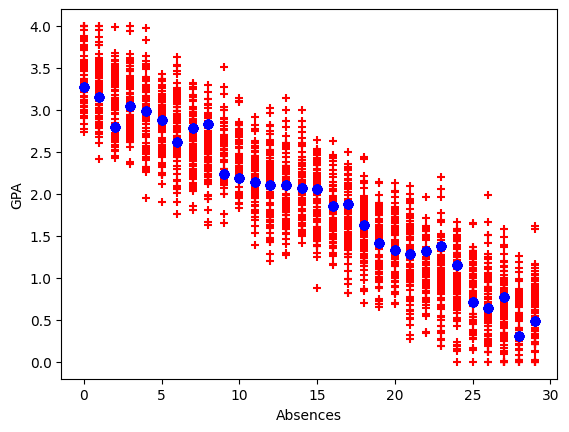

In [9]:
# Scatter plot of data
plt.xlabel('Absences')
plt.ylabel('GPA')
plt.scatter(df['Absences'], df['GPA'], color='red', marker='+')

# Plot predictions
plt.scatter(x_test, y_pred, color='blue')

plt.show()

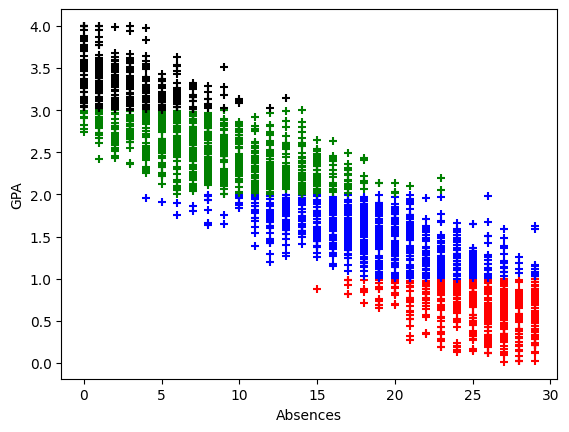

In [28]:
# Create GPA categories (Very Low, Low, Medium, High)
df['target'] = pd.cut(df['GPA'],
                      bins=[0, 1, 2, 3, 4.0],
                      labels=[0, 1, 2, 3])



# Split dataset into groups for plotting
dr0 = df[df.target==0]
dr1 = df[df.target==1]
dr2 = df[df.target==2]
dr3 = df[df.target==3]

# Scatter plot (Absences vs GPA groups)
plt.scatter(dr0['Absences'], dr0['GPA'], color='red', marker='+')
plt.scatter(dr1['Absences'], dr1['GPA'], color='blue', marker='+')
plt.scatter(dr2['Absences'], dr2['GPA'], color='green', marker='+')
plt.scatter(dr3['Absences'], dr3['GPA'], color='black', marker='+')

plt.xlabel("Absences")
plt.ylabel("GPA")
plt.show()

In [33]:
x = df.drop(['target'], axis='columns')
y = df.target

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=1)

len(x_train)
len(x_test)

476

In [39]:
# KNN model
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier()
knn.fit(x_train, y_train)

#not working

KNeighborsClassifier()

In [40]:
# Predictions and Confusion Matrix
from sklearn.metrics import confusion_matrix

y_pred = knn.predict(x_test)
cm = confusion_matrix(y_test, y_pred)
cm

array([[ 42,  58,   1,   0],
       [ 35,  82,  24,   0],
       [  3,  45, 114,   9],
       [  0,   3,  47,  13]])

In [41]:
# Last is the Classification report
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.53      0.42      0.46       101
           1       0.44      0.58      0.50       141
           2       0.61      0.67      0.64       171
           3       0.59      0.21      0.31        63

    accuracy                           0.53       476
   macro avg       0.54      0.47      0.48       476
weighted avg       0.54      0.53      0.52       476

